In [48]:
import numpy as np
from numpy.typing import NDArray

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from typing import List, Tuple

import json

In [49]:
# Define ClusterType as a tuple of two tuples representing bounding box coordinates, and an int representing number of pixels.
ClusterType = Tuple[(int, int), (int, int), int]

# Set the threshold value for binary thresholding (range: 0-255).
threshold_value = 127

graying_option = 3

img_path = 'images/product-manager-business-card.jpg'

TypeError: Tuple[t0, t1, ...]: each t must be a type. Got (<class 'int'>, <class 'int'>).

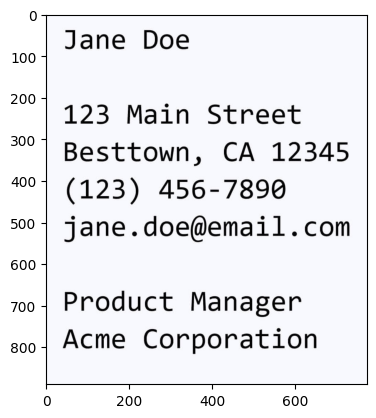

In [23]:
# Gets and shows selected img
img = np.array(Image.open(img_path))
plt.imshow(img)

In [24]:
def make_gray_copy(img: NDArray[np.uint8], graying_option: int, /, *, show: bool = False) -> NDArray[np.uint8]:
    """
    Creates a grayscale copy of the input RGB image using the specified method.

    Parameters
    ----------
    img : NDArray[np.uint8]
        The input RGB image as a NumPy array with shape (H, W, 3).
    graying_option : int
        Determines the method for generating the grayscale image:
        - 0: Use the red channel.
        - 1: Use the green channel.
        - 2: Use the blue channel.
        - 3: Use the average of all three channels.
    show : bool, optional
        If True, displays the grayscale image using matplotlib. Default is False.

    Returns
    -------
    NDArray[np.uint8]
        A 2D NumPy array representing the grayscale image.

    Raises
    ------
    ValueError
        If `graying_option` is not 0, 1, 2, or 3.
"""

    if graying_option not in (0, 1, 2, 3):
        raise ValueError(f"Graying option: {graying_option} not supported!")

    if graying_option == 3:
        gray_img = img.mean(axis=2)
    else:
        gray_img = np.copy(img[:, :, graying_option])

    if show: plt.imshow(gray_img, cmap="gray")

    return gray_img


In [25]:
def threshold_gray_img(gray_img: NDArray[np.uint8], threshold_value: int) -> NDArray[np.uint8]:
    """
   Applies binary thresholding to a grayscale image.

   Parameters
   ----------
   gray_img : NDArray[np.uint8]
       A 2D grayscale image as a NumPy array.
   threshold_value : int
       The threshold value (0–255). Pixels greater than this value are set to 255, 
       and others are set to 0.

   Returns
   -------
   NDArray[np.uint8]
       A binary image (values 0 or 255) of the same shape as the input.
   """
    return np.where(gray_img > threshold_value, 255, 0)


In [26]:
# The recursive approach fails on large images because it exceeds the stack limit.
def get_nearest(i: int, j: int, img: NDArray[np.uint8], bounds: List[int]):
    """
    Recursively explores 4-connected pixels starting from a given pixel with value 0,
    and updates the bounding box that encloses all connected pixels.

    Parameters
    ----------
    i : int
        The row index of the starting pixel.
    j : int
        The column index of the starting pixel.
    img : NDArray[np.uint8]
        A 2D array representing the image, where each element is an 8-bit unsigned integer.
    bounds : List[int]
        A list of four integers representing the current bounding box:
        [min_i, min_j, max_i, max_j, number_of_pixels]. The list is updated during recursion as the bounding box expands.

    Notes
    -----
    The function modifies the `img` array in-place by marking visited pixels with a value of 15.
    The bounding box is updated with the minimum and maximum values of the coordinates
    of the connected pixels. The recursive approach may fail on large images due to exceeding
    the stack limit. For larger images, an iterative approach may be preferred to avoid stack overflows.
    """

    if i < 0 or i >= img.shape[0] or j < 0 or j >= img.shape[1]:
        return
    if img[i][j] != 0:
        return

    img[i][j] = 15

    # Update bounding box
    bounds[0] = min(bounds[0], i)
    bounds[1] = min(bounds[1], j)
    bounds[2] = max(bounds[2], i)
    bounds[3] = max(bounds[3], j)

    bounds[4] += 1

    # ToDo na 8
    # Explore 4-connected neighbors
    get_nearest(i - 1, j, img, bounds)
    get_nearest(i + 1, j, img, bounds)
    get_nearest(i, j - 1, img, bounds)
    get_nearest(i, j + 1, img, bounds)


def find_clusters(img: NDArray[np.uint8]) -> List[ClusterType]:
    """
    Identifies clusters of connected pixels with a value of 0 in the given image and
    returns their bounding boxes.

    Parameters
    ----------
    img : NDArray[np.uint8]
        A 2D array representing the image, where each element is an 8-bit unsigned integer.

    Returns
    -------
    List[Tuple[Tuple[int, int], Tuple[int, int]]]
        A list of bounding boxes, where each bounding box is represented by a tuple
        of two tuples: (min_i, min_j) and (max_i, max_j). These bounding boxes represent
        the clusters of connected pixels in the image.

    Notes
    -----
    The function iterates over the image and, for each unvisited pixel with a value of 0,
    it recursively finds all connected pixels and updates the bounding box. The result
    is a list of bounding boxes, one for each cluster of connected pixels. The recursive
    method for finding clusters may fail on large images due to stack overflows, so
    an iterative approach may be more robust for larger images.
    """
    clusters = []

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i][j] == 0:
                bounds = [i, j, i, j, 0]
                get_nearest(i, j, img, bounds)
                clusters.append([(bounds[0], bounds[1]), (bounds[2], bounds[3]), bounds[4]])

    return clusters


In [56]:
def plot_clusters_on_img(img: NDArray[np.uint8], clusters: List[ClusterType]) -> None:
    """
    Plots the given image and overlays bounding boxes around detected clusters.

    Parameters
    ----------
    img : NDArray[np.uint8]
        A 2D numpy array representing the grayscale image on which clusters will be plotted. 
        Pixel values should be in the range [0, 255].
    
    clusters : List[ClusterType]
        A list of bounding boxes, where each bounding box is represented as a tuple of 
        two tuples: (min_i, min_j) and (max_i, max_j), defining the top-left and bottom-right 
        corners of the bounding box around a cluster.

    Returns
    -------
    None
        The function does not return any value but displays the image with overlaid bounding boxes.
    """
    fig, ax = plt.subplots()
    ax.imshow(img, cmap='gray')

    points = [item[:2] for item in clusters]
    for (min_pt, max_pt) in points:
        min_i, min_j = min_pt
        max_i, max_j = max_pt
        rect = patches.Rectangle(
            (min_j, min_i),  # (x, y)
            max_j - min_j + 1,  # width
            max_i - min_i + 1,  # height
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.title("Detected Clusters with Bounding Boxes")
    plt.axis('off')
    plt.show()

100


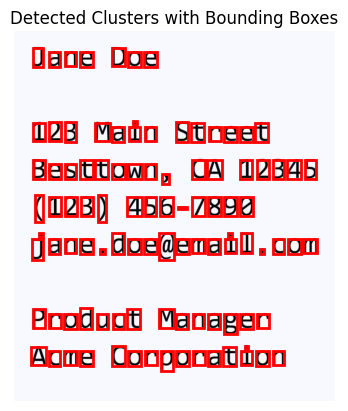

In [57]:
gray_img_2 = make_gray_copy(img, graying_option)
gray_img = threshold_gray_img(gray_img_2, threshold_value)
clusters = find_clusters(gray_img)
print(len(clusters))
plot_clusters_on_img(img, clusters)

In [74]:
# ToDo:
# 1. Poprawić readability
# 2. Poprawić format JSON'a
# 3. Dodać zapis jako obrazek .jpg

def save_clusters(clusters: List[ClusterType], file_name: str = "data", /, *, file_format: str = "csv") -> None:
    match file_format.lower():
        case "json":
            cluster_data = [{'min_x': min_i, 'min_y': min_j, 'max_x': max_i, 'max_y': max_j, 'pixel_count': pixel_count}
                            for (min_i, min_j), (max_i, max_j), pixel_count in clusters]

            with open(file_name + 'json', 'w') as file:
                json.dump(cluster_data, file, indent=4)
        case "csv":
            pass
        case _:
            raise Warning(f"File format: {file_format} not supported, using csv as default.")

    np.savetxt(file_name + '.csv',
               [[min_i, min_j, max_i, max_j, pixel_count] for (min_i, min_j), (max_i, max_j), pixel_count in clusters],
               delimiter=',', fmt="%d",header="min_x,min_y,max_x,max_y,pixel_count", comments="")


In [75]:
save_clusters(clusters, file_format="csv")
save_clusters(clusters, file_format="json")

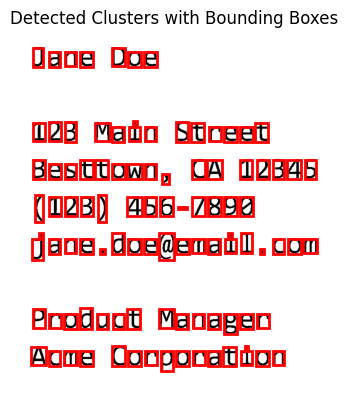

In [68]:
plot_clusters_on_img(gray_img, clusters)